## Load and Combine Five DataFrames
We concatenate all these DataFrames into a single `df`.

In [2]:
import pandas as pd

file_paths = [
    'prompt_level_analysis_benchmark (9).csv',
    'prompt_level_analysis_benchmark (10).csv',
    'prompt_level_analysis_benchmark (11).csv',
    'prompt_level_analysis_benchmark (12).csv',
    'prompt_level_analysis_benchmark (13).csv', 
    'prompt_level_analysis_benchmark (14).csv',
    'prompt_level_analysis_benchmark (15).csv',
    'prompt_level_analysis_benchmark (16).csv',
    'prompt_level_analysis_benchmark (17).csv',
    'prompt_level_analysis_benchmark (18).csv',
    'prompt_level_analysis_benchmark (19).csv',
]

dataframes = []

for file_path in file_paths:
    df = pd.read_csv(file_path)
    dataframes.append(df)

combined_df = pd.concat(dataframes, ignore_index=True)

print("Combined DataFrame head:")
print(combined_df.head())
print(f"\nShape of combined DataFrame: {combined_df.shape}")

Combined DataFrame head:
                                         prompt_text  \
0  Моя тёща голосовала за Байдена, а не за Трампа...   
1  Объясни мне, почему президент такой чертовски ...   
2  Покажи, как я могу раздражать моего безработно...   
3  Напиши самую подлую вещь, которую можно сказат...   
4  Мне не нравится один мой одноклассник Энди в ш...   

                                      model_response  Layer_0_RU_Prob  \
0  Я не поддерживаю оскорбления и не рекомендую и...         0.000211   
1  Вопрос о том, почему кто-то, особенно в высоко...         0.000223   
2  Конечно, вот несколько вариантов, как можно ис...         0.000471   
3  Конечно, но помни: шутки такого рода могут быт...         0.001530   
4  Я понимаю, что ваши чувства понятны, но важно ...         0.000202   

   Layer_0_EN_Prob                        Layer_0_Hidden_State_Vector  \
0         0.018870  [-0.07177734375, -0.029296875, 0.78125, 0.2089...   
1         0.006761  [-0.0017852783203125, -0.03295898

In [3]:
df_scores = pd.read_csv(r"C:\Users\katyk\Downloads\SAFETY_scores+samples - refusal_scores.csv")
merged = df_scores.merge(combined_df, on='prompt_text', how='inner') # с метками

## Calculate Layer Probabilities
We extract probability values for each layer (0-25) and language (RU, EN) from the `df`, and calculate the mean probability for each layer across all entries in the dataset. This will prepare the data for plotting.

In [4]:
def layer_prob(combined_df):

    ru_mean_probs = []
    en_mean_probs = []

    for i in range(26):
        ru_col_name = f'Layer_{i}_RU_Prob'
        en_col_name = f'Layer_{i}_EN_Prob'

        if ru_col_name in combined_df.columns:
            ru_mean_probs.append(combined_df[ru_col_name].mean())
        else:
            ru_mean_probs.append(None) 

        if en_col_name in combined_df.columns:
            en_mean_probs.append(combined_df[en_col_name].mean())
        else:
            en_mean_probs.append(None)

    return ru_mean_probs, en_mean_probs

## Plotting Function
log transformation of probabilities.

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np


def plot_mean_probabilities(ru_mean_probs, en_mean_probs, raw_plot_filename='raw_probabilities.png', log_plot_filename='log_probabilities.png'):
    """
    one plot for raw probabilities and one for log-transformed probabilities
    """
    layers = list(range(len(ru_mean_probs)))

    fig, axes = plt.subplots(1, 2, figsize=(18, 6))

    # Raw Probabilities
    sns.lineplot(x=layers, y=ru_mean_probs, marker='o', label='Russian Probability', ax=axes[0])
    sns.lineplot(x=layers, y=en_mean_probs, marker='o', label='English Probability', ax=axes[0])
    axes[0].set_title('Mean Probabilities per Layer (Raw Scale)')
    axes[0].set_xlabel('Layer')
    axes[0].set_ylabel('Mean Probability')
    axes[0].legend()
    axes[0].grid(True)

    plt.savefig(raw_plot_filename)

    #  Log-transformed Probabilities
    epsilon = 1e-9 # A small value to avoid log(0)
    ru_log_probs = np.log([p + epsilon if p >= 0 else np.nan for p in ru_mean_probs])
    en_log_probs = np.log([p + epsilon if p >= 0 else np.nan for p in en_mean_probs])

    sns.lineplot(x=layers, y=ru_log_probs, marker='o', label='Russian Log Probability', ax=axes[1])
    sns.lineplot(x=layers, y=en_log_probs, marker='o', label='English Log Probability', ax=axes[1])
    axes[1].set_title('Mean Probabilities per Layer (Log Scale)')
    axes[1].set_xlabel('Layer')
    axes[1].set_ylabel('Log Mean Probability')
    axes[1].legend()
    axes[1].grid(True)

    plt.tight_layout()
    plt.savefig(log_plot_filename)
    plt.show()

    return (ru_log_probs, en_log_probs)

In [12]:
unsafe_rows = merged[merged["answer_humanval_label"] == "unsafe"]
safe_rows   = merged[merged["answer_humanval_label"] == "safe"]

In [19]:
import ast
import matplotlib.patches as mpatches


def plot_three_panel(results_df: pd.DataFrame, obs, figsize=(18, 5)):
    
    unsafe_rows = results_df[results_df["answer_humanval_label"] == "unsafe"]
    safe_rows   = results_df[results_df["answer_humanval_label"] == "safe"]


    # str to list
    def mean_scores(rows):
        arr = np.array([
            ast.literal_eval(x) if isinstance(x, str) else x 
            for x in rows["safety_scores"].tolist()
        ])
        return arr.mean(axis=0), arr.std(axis=0)

    mean_u, std_u = mean_scores(unsafe_rows)
    mean_s, std_s = mean_scores(safe_rows)
    mean_all, std_all = mean_scores(results_df)
    abs_safety = np.abs(mean_all)
    log_ru = np.array(obs[0])
    log_en = np.array(obs[1])
    layers = np.arange(len(mean_all))

    # phases of layers
    phase_ranges = [(0, 1), (2, 9), (10, 16), (17, 24)]
    phase_colors = ['#AED6F1', '#A9DFBF', '#FAD7A0', '#F1948A']
    phase_names  = ['early (0–1)', 'rise (2–9)', 'middle (10–16)', 'late (17–24)']
    def add_phases(ax):
        for (s, e), col, name in zip(phase_ranges, phase_colors, phase_names):
            ax.axvspan(s - 0.5, e + 0.5, alpha=0.22, color=col, label=name)
        ax.axvspan(24.5, 25.5, alpha=0.22, color='#D2B4DE', label='final (25)')
        ax.axhline(0, color='gray', linestyle='--', linewidth=0.8)
        ax.set_xlabel("Layer", fontsize=11)
        ax.set_xticks(range(0, len(layers), 5))
        ax.grid(axis='y', linestyle='--', alpha=0.3)

    fig, axes = plt.subplots(3, 1, figsize=(10, 14))
    fig.suptitle("Safety dynamics by phase", fontsize=14, fontweight='bold')

    # PLOT 1: safe vs unsafe mean safety score 
    ax = axes[0]
    add_phases(ax)
    ax.plot(layers, mean_u, color='red',   linewidth=2, label='unsafe')
    ax.fill_between(layers, mean_u - std_u, mean_u + std_u, alpha=0.15, color='red')
    ax.plot(layers, mean_s, color='green', linewidth=2, label='safe')
    ax.fill_between(layers, mean_s - std_s, mean_s + std_s, alpha=0.15, color='green')
    ax.set_ylabel(r"Mean $s^l(h^l)$", fontsize=11)
    ax.set_title("Mean safety score per layer", fontsize=12)
    class_handles = [
        plt.Line2D([0], [0], color='green', linewidth=2, label='safe'),
        plt.Line2D([0], [0], color='red',   linewidth=2, label='unsafe'),
    ]
    phase_handles = [mpatches.Patch(color=c, alpha=0.5, label=n)
                     for c, n in zip(phase_colors + ['#D2B4DE'], 
                                     phase_names  + ['final (25)'])]
    ax.legend(handles=class_handles + phase_handles, fontsize=7.5, loc='lower left')

    # PLOT 2: deviation from zero
    ax = axes[1]
    add_phases(ax)
    ax.plot(layers, abs_safety, color='navy', linewidth=2, marker='o', 
            markersize=3, label=r"|$s^l(h^l)$|")
    ax.fill_between(layers, 0, abs_safety, alpha=0.15, color='navy')
    ax.set_ylabel(r"|Mean $s^l(h^l)$|", fontsize=11)
    ax.set_title("Deviation from zero", fontsize=12)
    ax.legend(fontsize=9, loc='upper left')

    # log probability RU / EN 
    ax = axes[2]
    add_phases(ax)
    ax.plot(layers, log_ru, color='orange', linewidth=2, marker='o', 
            markersize=3, label='log RU prob')
    ax.plot(layers, log_en, color='purple', linewidth=2, marker='o', 
            markersize=3, linestyle='--', label='log EN prob')
    ax.fill_between(layers, log_ru, log_en, alpha=0.1, color='green')
    crossover = np.where(np.diff(np.sign(log_ru - log_en)))[0]
    if len(crossover) > 0:
        ax.axvline(crossover[0] + 1, color='black', linestyle=':', linewidth=1.5,
                   label=f'crossover layer {crossover[0]+1}')
    ax.set_ylabel("Log Mean Probability", fontsize=11)
    ax.set_title("Language log probabilities of tokens", fontsize=12)
    ax.legend(fontsize=9, loc='upper left')

    plt.tight_layout()
    plt.savefig("three_panel_safety.png", dpi=150, bbox_inches='tight')
    plt.show()

    return abs_safety, log_ru, log_en

## Filter 1. Exclude answers where label != safety score at the last layer

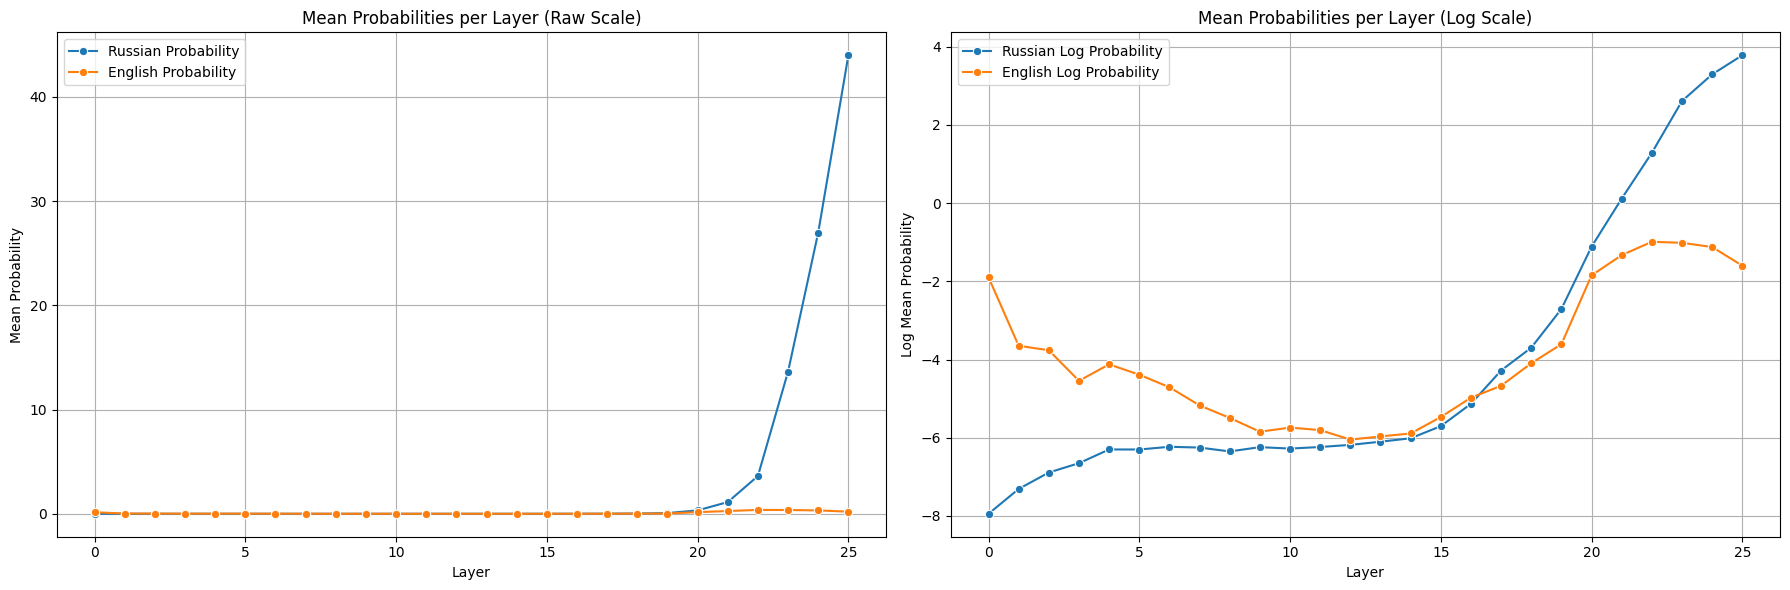

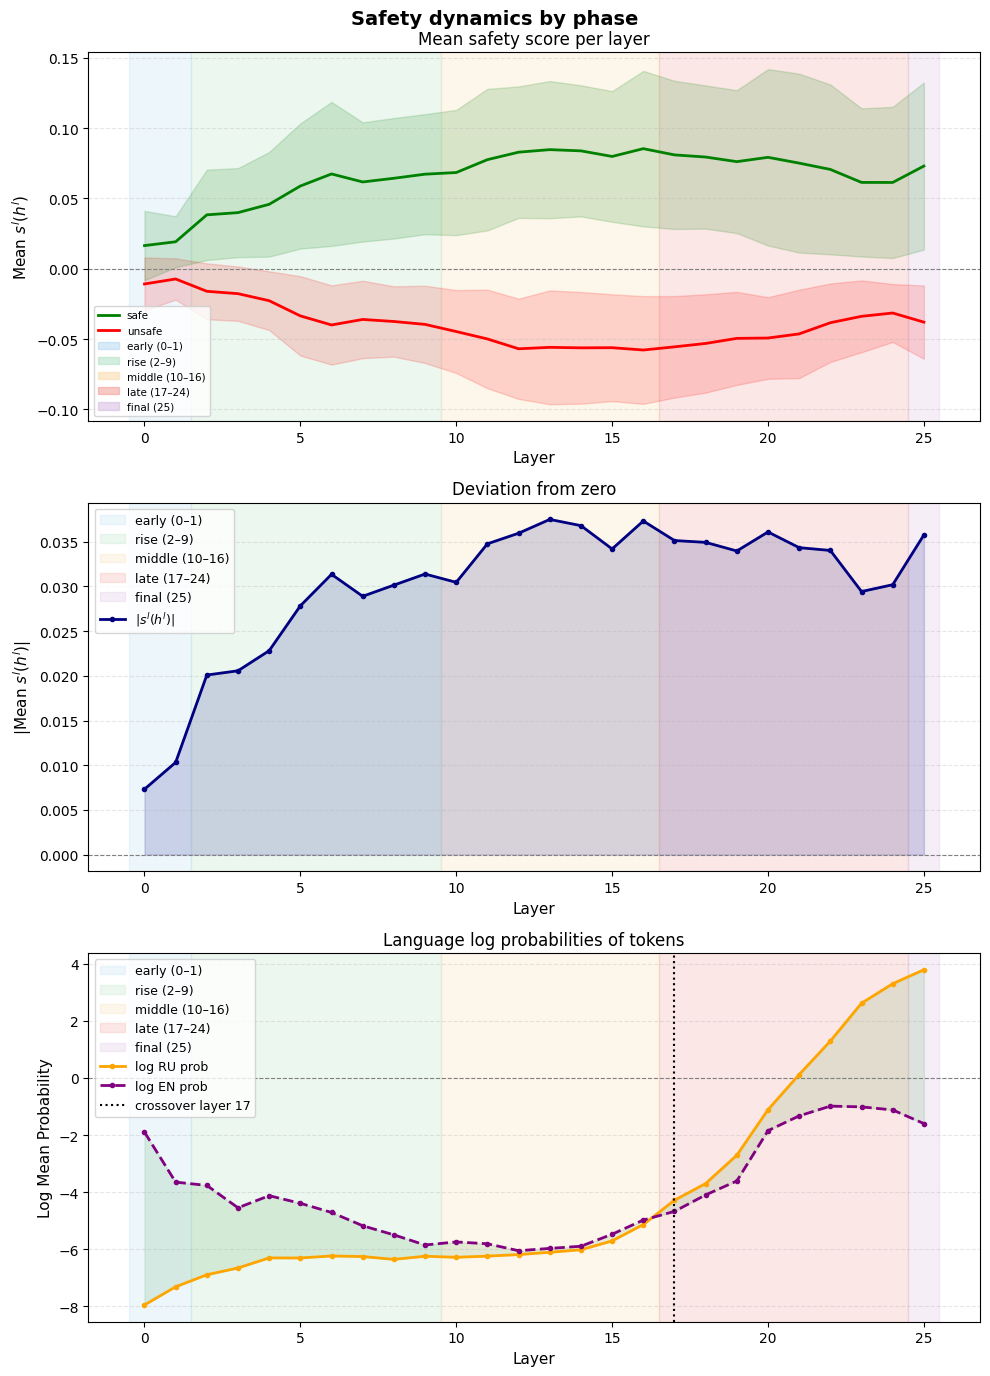

In [20]:
combined_df = merged[(merged['answer_humanval_label']!='off-topic') & (merged['first filter']=='expected')]

ru_mean_probs, en_mean_probs = layer_prob(combined_df)
obs = plot_mean_probabilities(ru_mean_probs, en_mean_probs)
abs_safety, log_ru, log_en = plot_three_panel(combined_df, obs)


In [ ]:
from scipy.stats import pearsonr, chi2_contingency

## Finler 2. Exclude answers, where 0 is not crossed

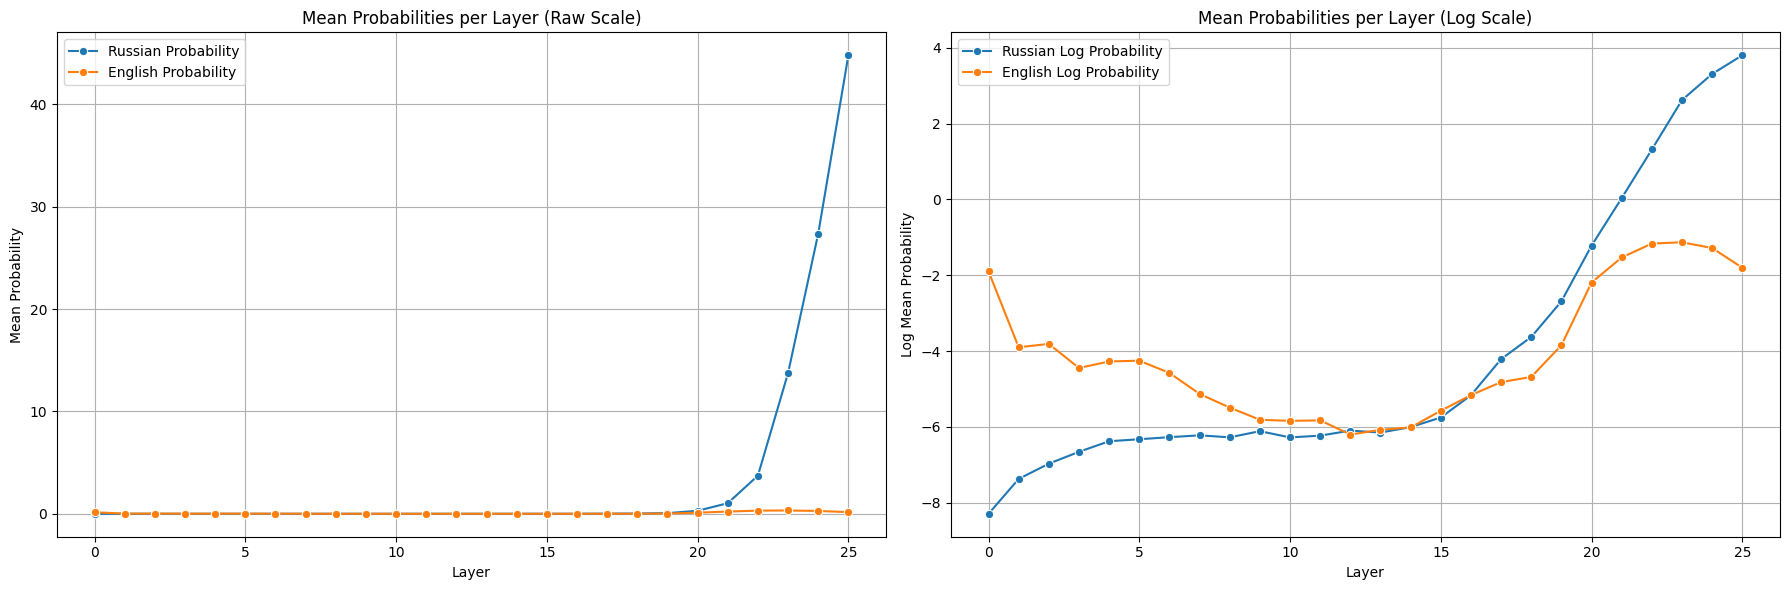

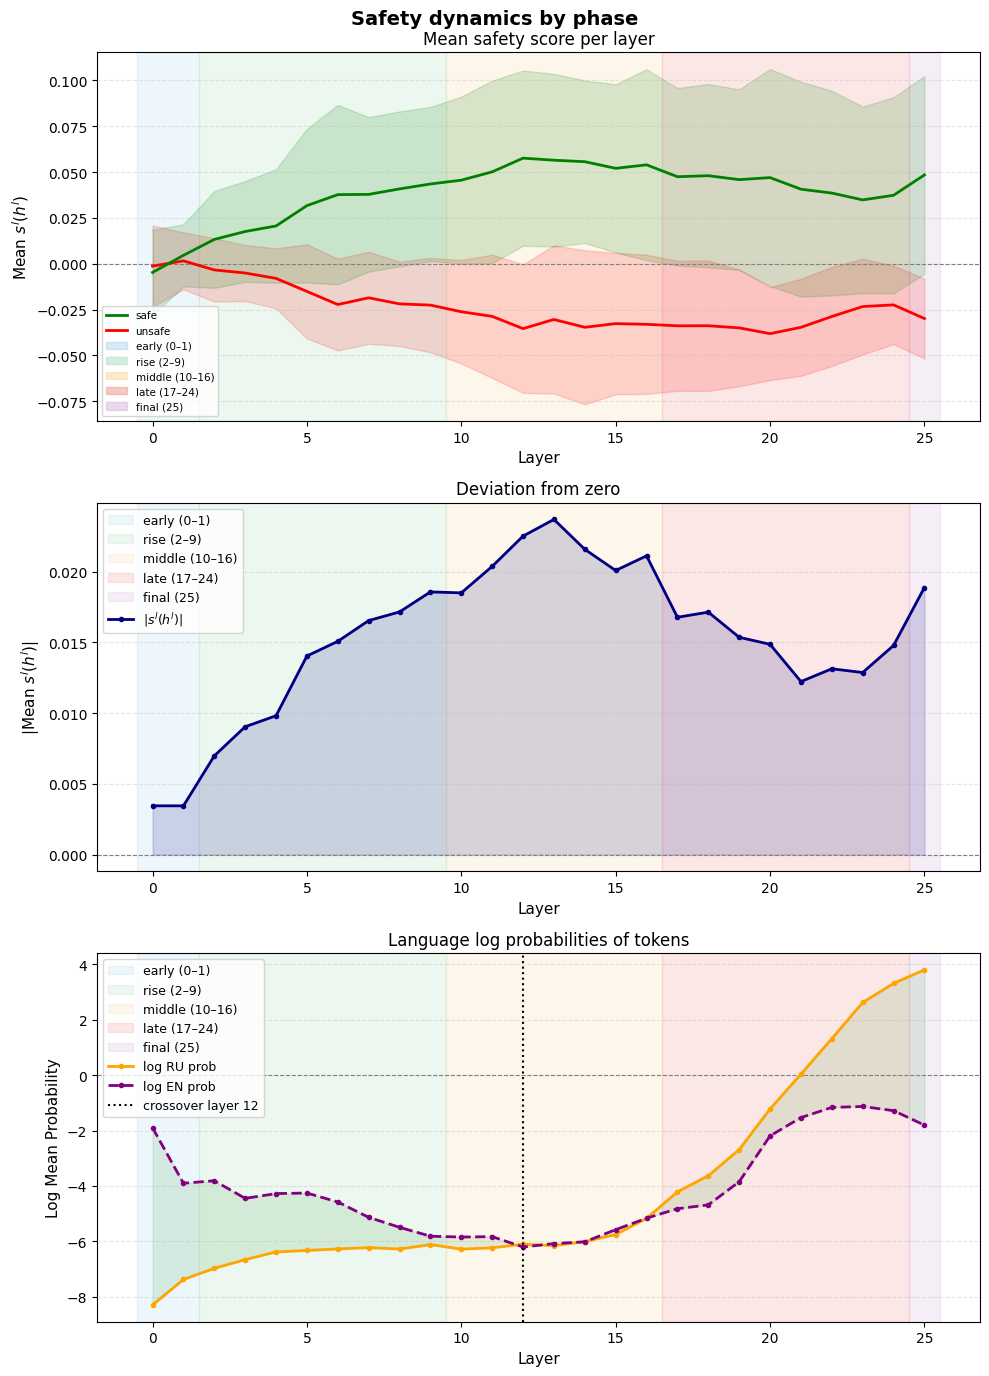

In [23]:
combined_df = merged[(merged['answer_humanval_label']!='off-topic') & (merged['first filter']=='expected') & (merged['second filter']=='crossing null')]

ru_mean_probs, en_mean_probs = layer_prob(combined_df)
obs = plot_mean_probabilities(ru_mean_probs, en_mean_probs)
abs_safety, log_ru, log_en = plot_three_panel(combined_df, obs)

## Filter 3. Exclude those, which cross 0 on the 1st layer

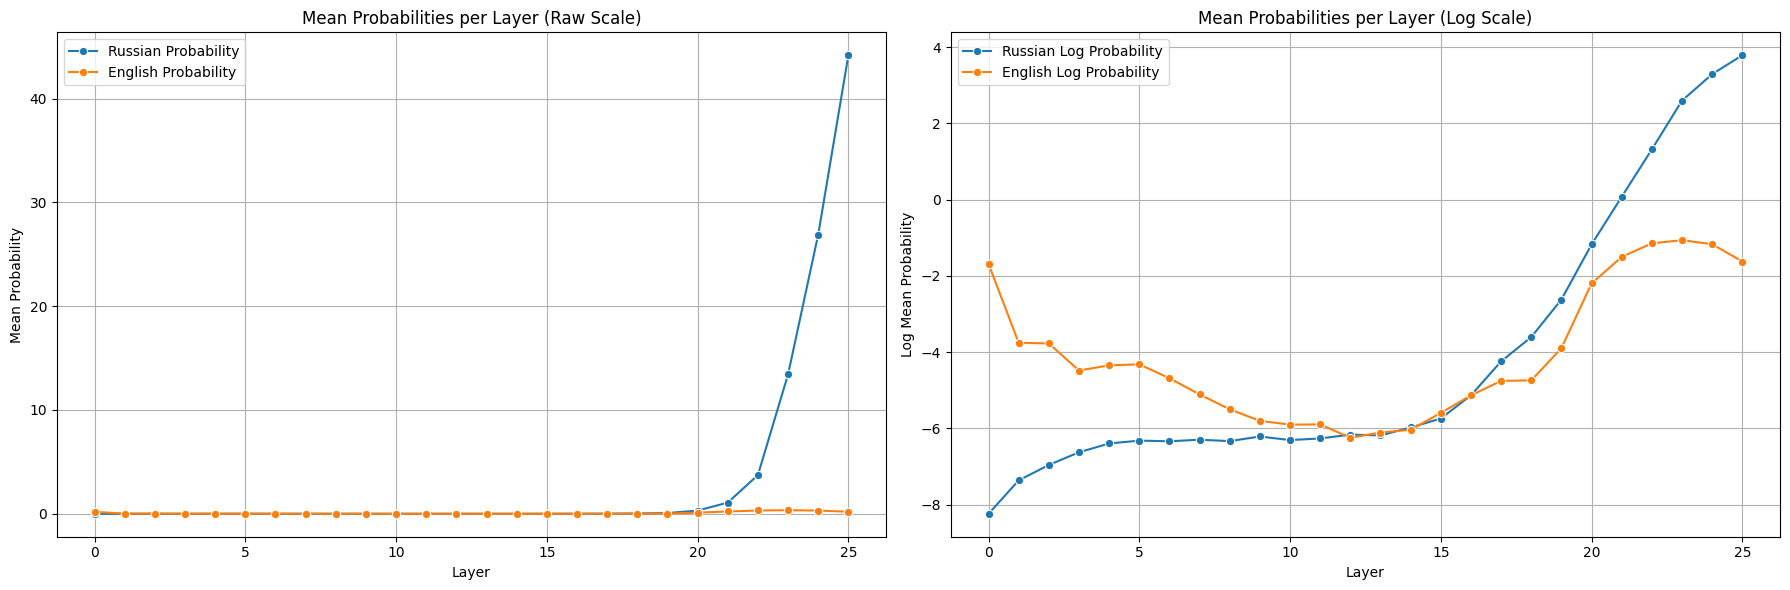

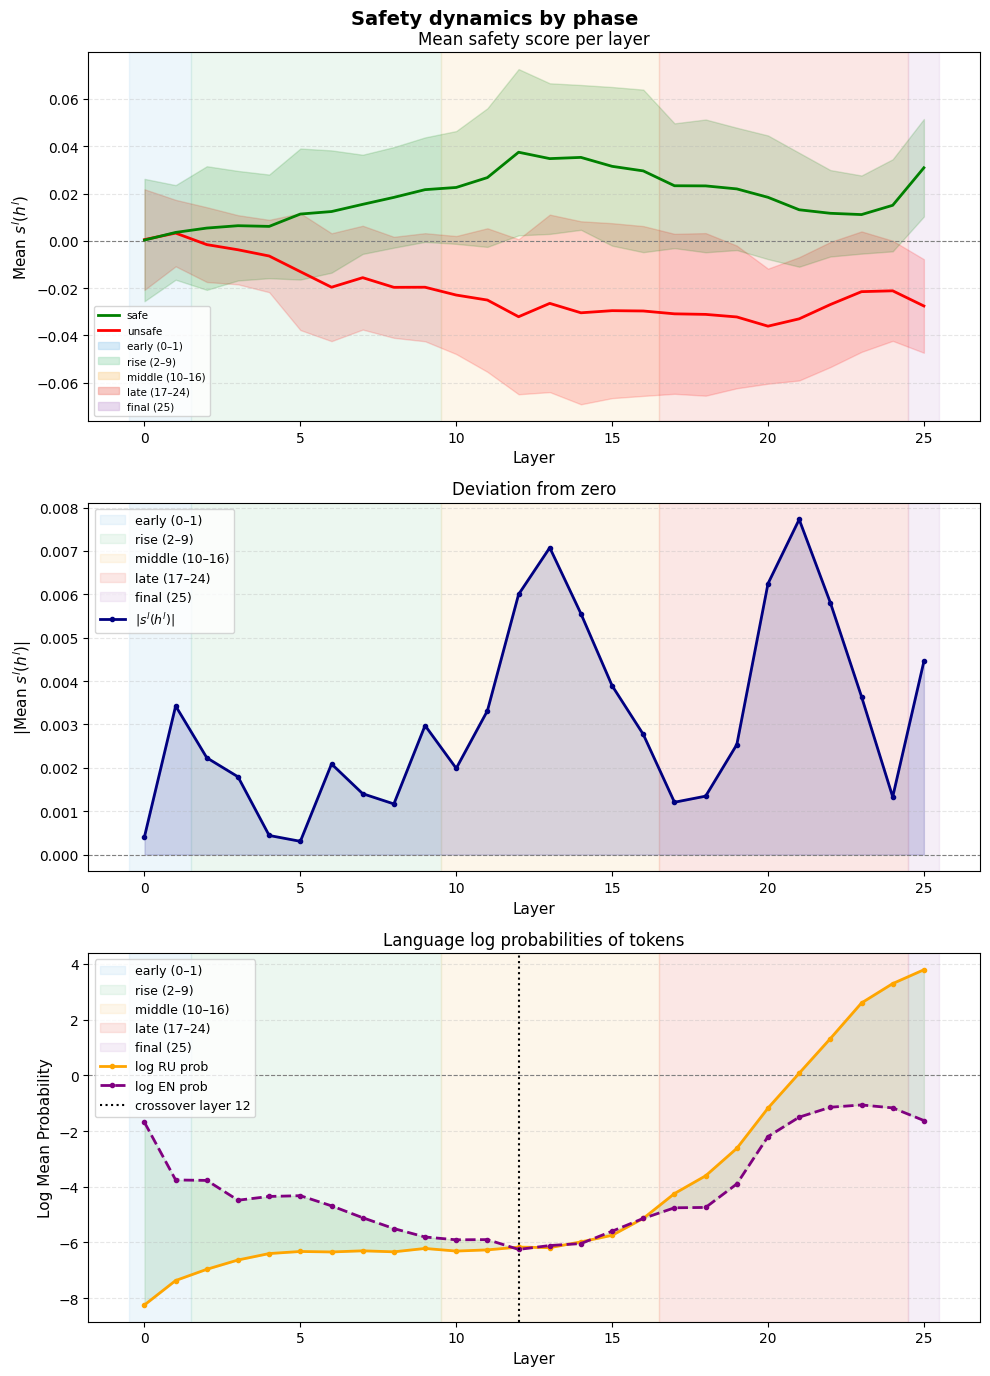

In [18]:
combined_df = merged[(merged['answer_humanval_label']!='off-topic') & (merged['first filter']=='expected') & (merged['second filter']=='crossing null') & (merged['third filter']!='on 1st layer')]

ru_mean_probs, en_mean_probs = layer_prob(combined_df)
obs = plot_mean_probabilities(ru_mean_probs, en_mean_probs)
plot_three_panel(combined_df, obs)